In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install opencv-python seaborn

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/Dataset_BUSI_with_GT"

In [ ]:
classes = ["benign","malignant","normal"]

images = []
labels = []

img_size = 224

for label, category in enumerate(classes):

    folder = os.path.join(dataset_path, category)

    for file in os.listdir(folder):

        if "_mask" in file:
            continue

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)
        img = cv2.resize(img,(img_size,img_size))
        img = img/255.0

        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Total images:",len(X))

Total images: 781


In [ ]:
y = to_categorical(y,3)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y,test_size=0.30,random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=42
)

print("Train:",len(X_train))
print("Validation:",len(X_val))
print("Test:",len(X_test))

Train: 546
Validation: 117
Test: 118


In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = Flatten()(x)

x = Dense(256,activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(3,activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 378s 11s/step - accuracy: 0.7894 - loss: 0.4495 - val_accuracy: 0.8205 - val_loss: 0.4665
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 358s 10s/step - accuracy: 0.7766 - loss: 0.4470 - val_accuracy: 0.8291 - val_loss: 0.4539
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 376s 11s/step - accuracy: 0.7967 - loss: 0.4285 - val_accuracy: 0.8376 - val_loss: 0.4505
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 357s 10s/step - accuracy: 0.8095 - loss: 0.4178 - val_accuracy: 0.8205 - val_loss: 0.4610
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 357s 10s/step - accuracy: 0.8297 - loss: 0.4037 - val_accuracy: 0.8547 - val_loss: 0.4270
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 358s 10s/step - accuracy: 0.8773 - loss: 0.3162 - val_accuracy: 0.8632 - val_loss: 0.4581
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 376s 11s/step - accuracy: 0.8590 - loss: 0.3223 - val_accuracy: 0.8803 - val_loss: 0.4243
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 358s 10s/step - accuracy: 0.8810 - loss: 0.2911 - val_accuracy: 0.

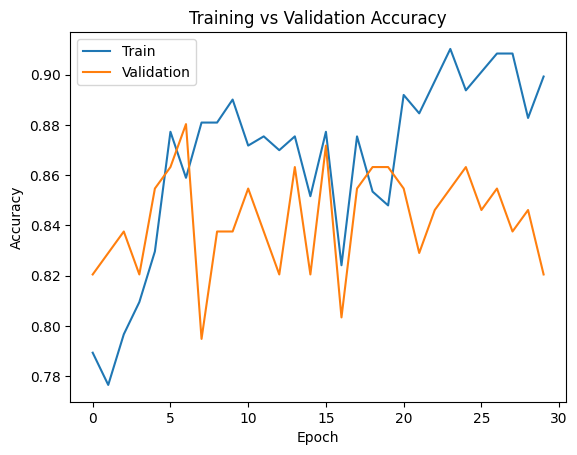

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

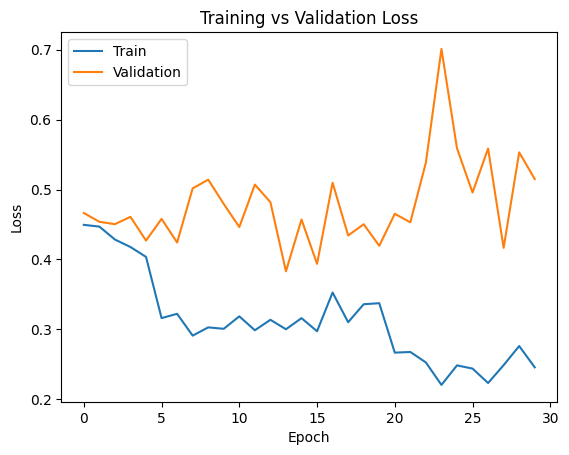

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test)

print("Test Accuracy:",test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 64s 15s/step - accuracy: 0.8475 - loss: 0.5981
Test Accuracy: 0.8474576473236084


In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 64s 15s/step


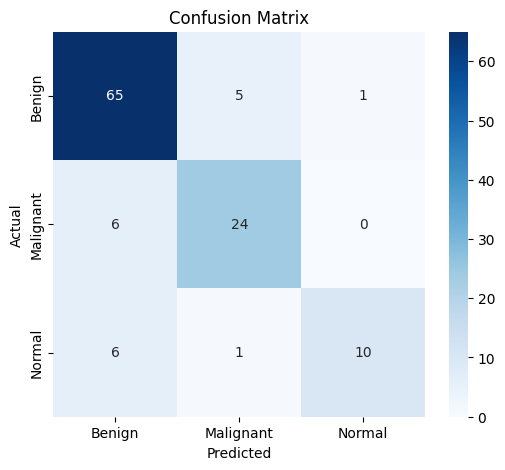

In [ ]:
cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant","Normal"],
    yticklabels=["Benign","Malignant","Normal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=["Benign","Malignant","Normal"]
))

              precision    recall  f1-score   support

      Benign       0.84      0.92      0.88        71
   Malignant       0.80      0.80      0.80        30
      Normal       0.91      0.59      0.71        17

    accuracy                           0.84       118
   macro avg       0.85      0.77      0.80       118
weighted avg       0.84      0.84      0.83       118

